
# LLM Starter Notebook — Mental-Health Forum Text (Template)

This notebook creates a **clean, modular scaffold** to build an LLM-based classifier or responder for mental-health forum text (e.g., Reddit).  
It includes **full preprocessing**, dataset building, tokenizer/model setup, **evaluation hooks**, and safe-inference helpers — but **does not run heavy training** by default.



## 1. Setup & Configuration

In [38]:


import os, re, glob, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Tuple, List
from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, recall_score, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM
from transformers import TrainingArguments, Trainer

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
DATA_DIR = "/kaggle/input/mentalhealthdata"   
PATTERN  = "*.csv"
OUTPUT_DIR = "./llm_scaffold_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Toggles
DO_CLASSIFICATION = True      # set True to prepare a triage classifier
DO_GENERATION     = True     # set True to prepare a supportive-reply generator
MAX_SAMPLES       = None      # e.g., 5000 for quick experiments


## 2. Preprocessing — Clean & Normalize

In [26]:

def clean_text(s: str) -> str:
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return "" if s.lower() == "nan" else s

def coerce_datetime(col: pd.Series) -> pd.Series:
    num = pd.to_numeric(col, errors="coerce")
    dt_from_epoch = pd.to_datetime(num, unit="s", errors="coerce")
    dt_from_str   = pd.to_datetime(col, errors="coerce")
    return dt_from_epoch.fillna(dt_from_str)

def map_file_to_class(files: List[str], lowercase=True) -> List[str]:
    raw = []
    for p in files:
        stem = os.path.splitext(os.path.basename(p))[0]
        token = stem.split("_", 1)[0] if "_" in stem else stem
        raw.append(token.strip().lower() if lowercase else token.strip())
    labels, seen = [], {}
    for lab in raw:
        if lab not in seen:
            seen[lab] = 1; labels.append(lab)
        else:
            seen[lab] += 1; labels.append(f"{lab}_{seen[lab]}")
    return labels

def load_and_clean(data_dir: str, pattern: str, max_samples=None) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir} with pattern {pattern}")
    classes = map_file_to_class(files, lowercase=True)
    frames = []
    for p, lab in zip(files, classes):
        df = pd.read_csv(p)
        df.insert(0, "condition_label", lab)
        frames.append(df)
    df = pd.concat(frames, ignore_index=True)

    # Ensure expected columns exist
    keep = ["condition_label","Title","Text","Top_10_Comments","Upvotes","Created_At","Author"]
    for c in keep:
        if c not in df.columns:
            df[c] = np.nan

    # Normalize text-ish columns
    for c in ["Title","Text","Top_10_Comments","Author","Created_At"]:
        df[c] = df[c].astype(str).map(clean_text)

    # Datetime & unified text views
    df["created_dt"]     = coerce_datetime(df["Created_At"])
    df["post_only_text"] = (df["Title"] + " " + df["Text"]).map(clean_text).str.lower()
    df["context_text"]   = (df["post_only_text"] + " " + df["Top_10_Comments"]).map(clean_text).str.lower()

    # Minimal filters
    df["token_cnt"] = df["context_text"].str.split().str.len()
    df = df[(df["context_text"] != "") & (df["token_cnt"] > 3)].copy()

    # Deduplicate by content
    df["_dup_key"] = df["context_text"].str.lower()
    df = df.drop_duplicates(subset=["_dup_key"]).drop(columns=["_dup_key"])

    df["Upvotes"] = pd.to_numeric(df["Upvotes"], errors="coerce").astype("Int64")

    if isinstance(max_samples, int) and len(df) > max_samples:
        df = df.sample(max_samples, random_state=SEED).reset_index(drop=True)
    return df.reset_index(drop=True)

df = load_and_clean(DATA_DIR, PATTERN, MAX_SAMPLES)
print("Rows:", len(df), "| Conditions:", df["condition_label"].nunique())
df.head(3)


Rows: 10439 | Conditions: 12


,condition_label,Title,Author,Upvotes,Text,Created_At,URL,Top_10_Comments,created_dt,post_only_text,context_text,token_cnt
0,adhd,My son's ADHD saved his sister's life,,15204,My son was only 7 years old when he took a pic...,2024-12-16 02:05:27,https://www.reddit.com/r/ADHD/comments/1hf8k5t...,Hi /u/Ollie-Branch and thanks for posting on /...,2024-12-16 02:05:27,my son's adhd saved his sister's life my son w...,my son's adhd saved his sister's life my son w...,1080
1,adhd,Reminder: If you made it to adulthood with lat...,Hipster-Deuxbag,7577,"We all know the statistics: 20,000 behavioral ...",2024-08-25 00:48:44,https://www.reddit.com/r/ADHD/comments/1f0k9en...,Hi /u/Hipster-Deuxbag and thanks for posting o...,2024-08-25 00:48:44,reminder: if you made it to adulthood with lat...,reminder: if you made it to adulthood with lat...,860
2,adhd,Children with higher IQ scores were diagnosed ...,Pretend_Voice_3140,4574,A study was published in the [British Journal ...,2024-11-05 12:24:31,https://www.reddit.com/r/ADHD/comments/1gk5ftv...,Hi /u/Pretend_Voice_3140 and thanks for postin...,2024-11-05 12:24:31,children with higher iq scores were diagnosed ...,children with higher iq scores were diagnosed ...,1114


## 3. Weak Triage Labels (Bootstrap) — Optional

In [27]:

# Simple, interpretable bootstrap labels (green/amber/red/crisis) for prototyping
kw_crisis = [
    "suicide","kill myself","end my life","want to die","self harm","self-harm",
    "overdose","can't go on","i'm done","ending it","hurt myself","hang myself"
]
kw_red = [
    "hopeless","no way out","worthless","can't cope","severe","cutting","relapse",
    "panic attack","shaking","numb","empty all the time","voice telling me","visions"
]
kw_amber = [
    "anxious","anxiety","depressed","depression","overwhelmed","crying",
    "can't sleep","insomnia","very stressed","please help","need help","advice please"
]

def make_weak_triage(text_series: pd.Series) -> pd.Series:
    text = text_series.fillna("").astype(str).str.lower()
    pat_crisis = re.compile("|".join([re.escape(k) for k in kw_crisis]))
    pat_red    = re.compile("|".join([re.escape(k) for k in kw_red]))
    pat_amber  = re.compile("|".join([re.escape(k) for k in kw_amber]))
    has_crisis = text.str.contains(pat_crisis, na=False)
    has_red    = text.str.contains(pat_red, na=False)
    has_amber  = text.str.contains(pat_amber, na=False)
    triage = np.where(has_crisis, "crisis",
              np.where(has_red, "red",
              np.where(has_amber, "amber", "green")))
    return pd.Series(triage, index=text.index)

# Attach weak labels (remove if you have gold labels)
df["triage_label"] = make_weak_triage(df["context_text"])
df["triage_label"].value_counts()


triage_label
red       3033
amber     2802
crisis    2480
green     2124
Name: count, dtype: int64

## 4. Optional Sanity Baseline (TF-IDF + LogReg)

              precision    recall  f1-score   support

       amber      0.615     0.632     0.623       560
      crisis      0.806     0.770     0.788       496
       green      0.589     0.760     0.664       425
         red      0.763     0.616     0.682       607

    accuracy                          0.686      2088
   macro avg      0.693     0.695     0.689      2088
weighted avg      0.698     0.686     0.688      2088



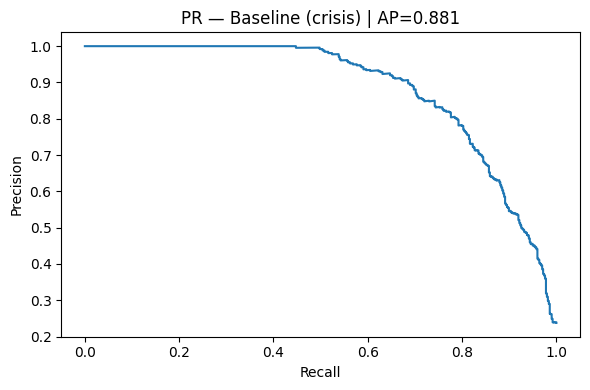

In [28]:

# Quick baseline to sanity-check the pipeline; safe to skip if focusing only on LLMs.
X = df["context_text"].values
y = df["triage_label"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=200_000)
Xtr = vec.fit_transform(X_tr)
Xte = vec.transform(X_te)

classes = np.unique(y_tr)
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
cw_map = {c:w for c,w in zip(classes, cw)}

logreg = LogisticRegression(
    solver="saga", multi_class="multinomial", penalty="l2",
    class_weight=cw_map, max_iter=3000, n_jobs=1, verbose=0
).fit(Xtr, y_tr)

pred = logreg.predict(Xte)
print(classification_report(y_te, pred, digits=3))

# Crisis PR (if present)
if hasattr(logreg, "predict_proba") and "crisis" in logreg.classes_:
    proba = logreg.predict_proba(Xte)
    labs  = logreg.classes_.tolist()
    idx   = labs.index("crisis")
    y_true_bin = (np.array(y_te)=="crisis").astype(int)
    prec, rec, thr = precision_recall_curve(y_true_bin, proba[:, idx])
    ap = average_precision_score(y_true_bin, proba[:, idx])
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    plt.title(f"PR — Baseline (crisis) | AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()


## 5. LLM — Classification Scaffold (BERT)

In [36]:

if DO_CLASSIFICATION:
    MODEL_NAME = "bert-base-uncased"   # swap to domain model if available
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    X = df["context_text"].values
    y = df["triage_label"].values
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

    # Encode labels
    uniq = np.unique(y_tr)
    label2id = {lab:i for i, lab in enumerate(sorted(uniq))}
    id2label = {i:lab for lab,i in label2id.items()}
    y_tr_enc = np.array([label2id[v] for v in y_tr], dtype=int)
    y_te_enc = np.array([label2id[v] for v in y_te], dtype=int)

    def to_hf(texts, labels):
        return Dataset.from_dict({"text": list(texts), "label": list(labels)})

    train_ds = to_hf(X_tr, y_tr_enc)
    test_ds  = to_hf(X_te, y_te_enc)

    def tok_fn(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

    train_tok = train_ds.map(tok_fn, batched=True)
    test_tok  = test_ds.map(tok_fn, batched=True)

    cols = ["input_ids","attention_mask","label"]
    train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols])
    test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in cols])

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(id2label), id2label=id2label, label2id=label2id
    )

    args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, "bert_triage"),
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,        
        save_strategy="no",
        logging_steps=50,
        report_to=[]
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        macro = f1_score(labels, preds, average="macro")
        # crisis recall if label exists
        crisis_id = label2id.get("crisis", None)
        cri = recall_score((labels==crisis_id), (preds==crisis_id)) if crisis_id is not None else float("nan")
        return {"macro_f1": macro, "crisis_recall": cri}

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_tok, eval_dataset=test_tok,
        tokenizer=tokenizer, compute_metrics=compute_metrics
    )

    print("**Ready to train** — Uncomment the next line when you want to run fine-tuning.")
    trainer.train()

    # Quick eval without training (randomly initialized head → rubbish metrics, but pipeline check)
    eval_out = trainer.evaluate()
    print(json.dumps(eval_out, indent=2))


Map:   0%|          | 0/8351 [00:00<?, ? examples/s]

Map:   0%|          | 0/2088 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_37/1047123059.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


**Ready to train** — Uncomment the next line when you want to run fine-tuning.


Step,Training Loss
50,1.391300
100,1.276500
150,1.228800
200,1.083000
250,1.007000
300,0.933700
350,0.927800


KeyboardInterrupt: 

## 6. LLM — Generation Scaffold (Supportive Reply)

In [39]:

if DO_GENERATION:
    GEN_MODEL = "google/flan-t5-small"   # small & friendly; swap as needed
    gen_tok   = AutoTokenizer.from_pretrained(GEN_MODEL)
    gen_model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL)

    def make_prompt(category, title, post, comments):
        return (
            "You are a supportive, non-clinical assistant. Be empathetic, boundaried, and encourage professional help when appropriate.\n\n"
            f"Category: {category}\nTitle: {title}\nPost: {post}\nSome comments: {comments}\n\n"
            "Write a short, compassionate reply (120–180 words). Avoid medical advice."
        )

    RISK_CUES = [
        "suicide","kill myself","end it","end my life","self harm","self-harm","overdose",
        "can't go on","want to die","hurt myself","hurt myself on purpose"
    ]
    CRISIS_TEMPLATE = (
        "I'm really sorry you're feeling this way. If you are in immediate danger or thinking about harming yourself, "
        "please contact your local emergency number right now. If you can, reach out to someone you trust. "
        "You deserve support and safety."
    )

    def safe_generate(category, title, post, comments, max_new_tokens=160):
        raw = f"{title} {post} {comments}".lower()
        if any(k in raw for k in RISK_CUES):
            return CRISIS_TEMPLATE
        prompt = make_prompt(category, title, post, comments)
        inputs = gen_tok([prompt], return_tensors="pt", truncation=True, max_length=512)
        out = gen_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.7, top_p=0.9)
        return gen_tok.decode(out[0], skip_special_tokens=True)

    # Demo (comment/uncomment to test once model is loaded)
    print(safe_generate("anxiety", "Heart racing at night", "Can't sleep; spirals of worry.", "try journaling | breathing helps"))


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

TypeError: DynamicCache.__init__() got an unexpected keyword argument 'config'

## 7. Saving Artifacts & Next Steps

In [32]:

# Save cleaned dataset snapshot
snap_path = os.path.join(OUTPUT_DIR, "clean_snapshot.parquet")
df.head(200).to_parquet(snap_path, index=False)
print("Saved snapshot:", snap_path)

print("""
**Next Steps**
1) Turn on training (uncomment `trainer.train()` in the classification section).
2) Increase epochs/batch size; add early stopping & class weighting if needed.
3) Create a **gold-standard** labeled slice (n≈300) for true evaluation; report macro-F1 and **crisis recall**.
4) Add SHAP or coefficients to provide human-readable explanations.
5) Export an inference function + threshold policy (e.g., escalate if p(crisis) ≥ 0.40).
"""")


SyntaxError: unterminated string literal (detected at line 13) (3663355609.py, line 13)